In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report,accuracy_score

In [2]:
data_path = "../data/processed/data_processed.csv"
df = pd.read_csv(data_path, parse_dates=['date'])

In [3]:
df_sort = df.sort_values(by=['date', 'city']).reset_index(drop=True)
df_sort.head(24)

,city,latitude,longitude,date,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,wind_speed_10m_mean,relative_humidity_2m_mean,...,dewpoint_2m_mean_lag_2,surface_pressure_mean_lag_2,cloudcover_mean_lag_2,wind_speed_10m_mean_lag_2,temperature_2m_mean_rolling_mean_3,relative_humidity_2m_mean_rolling_mean_3,dewpoint_2m_mean_rolling_mean_3,surface_pressure_mean_rolling_mean_3,cloudcover_mean_rolling_mean_3,wind_speed_10m_mean_rolling_mean_3
0,0,10.5417,107.2429,2014-01-08,-0.342105,0.125,1.0,1,0.500000,-0.760300,...,-0.985729,-0.203617,-0.371907,1.020833,-0.456140,-0.913858,-0.970438,-0.170127,-0.431226,8.750000e-01
1,1,16.0544,108.2022,2014-01-08,-1.447368,0.000,0.0,0,-0.208333,0.513109,...,-1.514781,0.813128,-1.406648,0.416667,-1.526316,0.059925,-1.379545,0.857111,-0.917771,2.986111e-01
2,2,10.9465,106.8340,2014-01-08,-0.157895,0.000,0.0,0,-0.604167,-0.992509,...,-0.891947,0.249163,-0.563859,-0.354167,-0.184211,-0.955212,-0.832144,0.282206,-0.683163,-3.125000e-01
3,3,21.0278,105.8342,2014-01-08,-2.263158,0.750,5.0,1,0.333333,-0.322097,...,-1.745158,0.386470,-0.285929,0.645833,-2.040570,-0.107366,-1.974176,0.503907,-0.792802,1.944444e-01
4,4,10.7769,106.7009,2014-01-08,-0.078947,0.000,0.0,0,-0.479167,-1.116105,...,-0.917431,0.149364,-0.490877,-0.270833,-0.192982,-0.928527,-0.852531,0.182407,-0.596184,-2.187500e-01
5,5,16.4637,107.5909,2014-01-08,-1.342105,0.000,0.0,0,-0.520833,0.599251,...,-1.406728,0.676490,-1.710572,0.645833,-1.385965,-0.057428,-1.309888,0.740567,-1.215696,3.333333e-01
6,6,12.2585,109.0526,2014-01-08,-1.000000,0.000,0.0,0,1.187500,-0.026217,...,-1.357798,0.586738,-1.106723,1.229167,-0.991228,-0.714107,-1.325858,0.608618,-1.039074,1.451389e+00
7,7,10.5336,106.4110,2014-01-08,-0.236842,0.000,0.0,0,-0.479167,-0.715356,...,-0.772681,0.298727,-0.323919,-0.250000,-0.298246,-0.711610,-0.731906,0.330208,-0.473215,-2.291667e-01
8,8,15.5394,108.0191,2014-01-08,-1.394737,0.000,0.0,0,-0.687500,0.389513,...,-1.499490,0.172806,-1.374656,-0.291667,-1.438596,-0.084894,-1.392796,0.217013,-0.760477,-3.541667e-01
9,9,21.0064,107.2925,2014-01-08,-2.473684,0.700,2.0,1,1.630208,-0.168539,...,-1.746177,0.791695,-0.065984,0.291667,-2.307018,0.222222,-1.998301,0.878321,-0.404566,3.125000e-01


In [4]:
def split_data(df, val_year = 2, test_year = 1):
    years = df['date'].dt.year.unique()
    print(years)
    val_years = years[-(val_year+test_year):-test_year]
    print(val_years)
    test_years = years[-test_year:]
    train_data = df[~df['date'].dt.year.isin(val_years)].reset_index(drop=True)
    val_data = df[df['date'].dt.year.isin(val_years)].reset_index(drop=True)
    test_data = df[df['date'].dt.year.isin(test_years)].reset_index(drop=True)
    return train_data, val_data, test_data

In [5]:
train_data, val_data, test_data = split_data(df_sort, val_year=2, test_year=1)

[2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
[2022 2023]


In [6]:
train_data.to_csv("../data/processed/train_data.csv", index=False)
val_data.to_csv("../data/processed/val_data.csv", index=False)
test_data.to_csv("../data/processed/test_data.csv", index=False)

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39372 entries, 0 to 39371
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   city                                      39372 non-null  int64         
 1   latitude                                  39372 non-null  float64       
 2   longitude                                 39372 non-null  float64       
 3   date                                      39372 non-null  datetime64[ns]
 4   temperature_2m_mean                       39372 non-null  float64       
 5   rain_sum                                  39372 non-null  float64       
 6   precipitation_hours                       39372 non-null  float64       
 7   weather_code                              39372 non-null  int64         
 8   wind_speed_10m_mean                       39372 non-null  float64       
 9   relative_humidity_2m_mean   

In [8]:
val_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   city                                      8760 non-null   int64         
 1   latitude                                  8760 non-null   float64       
 2   longitude                                 8760 non-null   float64       
 3   date                                      8760 non-null   datetime64[ns]
 4   temperature_2m_mean                       8760 non-null   float64       
 5   rain_sum                                  8760 non-null   float64       
 6   precipitation_hours                       8760 non-null   float64       
 7   weather_code                              8760 non-null   int64         
 8   wind_speed_10m_mean                       8760 non-null   float64       
 9   relative_humidity_2m_mean     

In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4392 entries, 0 to 4391
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   city                                      4392 non-null   int64         
 1   latitude                                  4392 non-null   float64       
 2   longitude                                 4392 non-null   float64       
 3   date                                      4392 non-null   datetime64[ns]
 4   temperature_2m_mean                       4392 non-null   float64       
 5   rain_sum                                  4392 non-null   float64       
 6   precipitation_hours                       4392 non-null   float64       
 7   weather_code                              4392 non-null   int64         
 8   wind_speed_10m_mean                       4392 non-null   float64       
 9   relative_humidity_2m_mean     

### CONFIG

In [12]:
# Col to predict
target_column = 'rain_sum'
side_target = ['precipitation_hours', 'weather_code', "date"]

drop_cols = ['surface_pressure_mean', 'wind_speed_10m_mean','cloudcover_mean', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'rain_sum','precipitation_hours', 'weather_code', 'date']

target_chaining = ['surface_pressure_mean',
    'wind_speed_10m_mean',
    'cloudcover_mean',
    'temperature_2m_mean',
    'relative_humidity_2m_mean',
    'precipitation_hours',
    'rain_sum']
# Define training and testing sets
X_train = train_data.drop(columns=drop_cols)
X_train_chain = X_train.copy()
Y_train_chain = train_data[target_chaining]
X_test = val_data.drop(columns=drop_cols)
Y_test_chain = val_data[target_chaining]


# METRICS


# XGBOOST

1. Model

In [11]:
import xgboost as xgb
import joblib
from sklearn.multioutput import RegressorChain
from xgboost import XGBRegressor, XGBClassifier
# Cấu hình XGBoost gốc
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'objective': 'reg:squarederror',
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}
# Khởi tạo RegressorChain
# order=None mặc định sẽ theo thứ tự cột trong Y_train_chain.
# Vì ta đã sắp xếp list 'chain_features' theo ý đồ rồi nên để order=None hoặc [0, 1, 2...]
reg_chain = RegressorChain(
    base_estimator=XGBRegressor(**xgb_params),
    order=None, 
    random_state=42
)

# Train Chain
print("Training Regressor Chain...")
reg_chain.fit(X_train_chain, Y_train_chain)

# Train Weather Code Classifier riêng biệt (vì nó là classification)
print("Training Weather Code Classifier...")
clf_weather = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    scale_pos_weight=5,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(train_data['weather_code'].unique()),
    n_jobs=-1
)
# Input cho Classifier nên bao gồm cả các biến vừa dự báo được từ Chain (tùy chọn nâng cao)
# Ở đây ta dùng X_train gốc cho đơn giản, hoặc bạn có thể nối thêm Y_train_chain vào X_train
clf_weather.fit(X_train, train_data['weather_code'])

Training Regressor Chain...
Training Weather Code Classifier...


C:\Users\buiti\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [21:27:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_class=2, ...)

In [ ]:
Y_pred_chain = reg_chain.predict(X_test) 

# Y_pred_chain là numpy array, ta cần map lại vào tên cột để in ra
evaluation_results = {}

for idx, col_name in enumerate(target_chaining):
    # Lấy cột dự báo tương ứng
    y_pred = Y_pred_chain[:, idx]
    y_true = Y_test_chain[col_name]
    
    # Xử lý hậu kỳ (Post-processing): Mưa và độ ẩm không được âm
    if col_name in ['rain_sum', 'precipitation_hours', 'wind_speed_10m_mean', 'relative_humidity_2m_mean']:
        y_pred = np.maximum(y_pred, 0) # Gán các giá trị < 0 thành 0

    # Tính metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    evaluation_results[col_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}
    print(f"{col_name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# B. Đánh giá Weather Code (Classification)
y_pred_code = clf_weather.predict(X_test)
y_true_code = val_data['weather_code']

print("\nWeather Code - Classification Report:")    
print(classification_report(y_true_code, y_pred_code))

surface_pressure_mean - MAE: 0.1388, MSE: 0.0365, RMSE: 0.1910
wind_speed_10m_mean - MAE: 0.3967, MSE: 0.2492, RMSE: 0.4992
cloudcover_mean - MAE: 0.3180, MSE: 0.1732, RMSE: 0.4161
temperature_2m_mean - MAE: 0.1267, MSE: 0.0301, RMSE: 0.1735
relative_humidity_2m_mean - MAE: 0.4591, MSE: 0.5043, RMSE: 0.7102
precipitation_hours - MAE: 3.1518, MSE: 19.2785, RMSE: 4.3907
rain_sum - MAE: 3.8757, MSE: 63.0666, RMSE: 7.9414

Weather Code - Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.53      0.61      1971
           1       0.87      0.94      0.90      6789

    accuracy                           0.84      8760
   macro avg       0.79      0.73      0.75      8760
weighted avg       0.84      0.84      0.84      8760



In [37]:
joblib.dump(reg_chain, f"../models/xgboost/reg_chain_model.pkl")
joblib.dump(clf_weather, f"../models/xgboost/clf_model.pkl")

['../models/xgboost/clf_model.pkl']

# RANDOM_FOREST

In [39]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

rf_params = {    'n_estimators':500,
    'max_depth':6,
    'min_samples_leaf' : 10,
    'min_samples_split' : 20,
    'max_features' : 'sqrt',
    'n_jobs':-1}

reg_chain = RegressorChain(
    base_estimator=RandomForestRegressor(**rf_params),
    order=None, 
    random_state=42
)

reg_chain.fit(X_train_chain, Y_train_chain)

clf_weather = RandomForestClassifier(**rf_params, class_weight ='balanced')

clf_weather.fit(X_train, train_data['weather_code'])

RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=500, n_jobs=-1)

In [40]:
Y_pred_chain = reg_chain.predict(X_test) 

# Y_pred_chain là numpy array, ta cần map lại vào tên cột để in ra
evaluation_results = {}

for idx, col_name in enumerate(target_chaining):
    # Lấy cột dự báo tương ứng
    y_pred = Y_pred_chain[:, idx]
    y_true = Y_test_chain[col_name]
    
    # Xử lý hậu kỳ (Post-processing): Mưa và độ ẩm không được âm
    if col_name in ['rain_sum', 'precipitation_hours', 'wind_speed_10m_mean', 'relative_humidity_2m_mean']:
        y_pred = np.maximum(y_pred, 0) # Gán các giá trị < 0 thành 0

    # Tính metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    evaluation_results[col_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}
    print(f"{col_name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# B. Đánh giá Weather Code (Classification)
y_pred_code = clf_weather.predict(X_test)
y_true_code = val_data['weather_code']

print("\nWeather Code - Classification Report:")
print(classification_report(y_true_code, y_pred_code))

surface_pressure_mean - MAE: 0.2055, MSE: 0.0795, RMSE: 0.2819
wind_speed_10m_mean - MAE: 0.4173, MSE: 0.2781, RMSE: 0.5274
cloudcover_mean - MAE: 0.3496, MSE: 0.1943, RMSE: 0.4408
temperature_2m_mean - MAE: 0.1714, MSE: 0.0602, RMSE: 0.2454
relative_humidity_2m_mean - MAE: 0.4826, MSE: 0.5201, RMSE: 0.7212
precipitation_hours - MAE: 3.4636, MSE: 21.4923, RMSE: 4.6360
rain_sum - MAE: 4.0647, MSE: 66.1478, RMSE: 8.1331

Weather Code - Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.78      0.64      1971
           1       0.93      0.81      0.86      6789

    accuracy                           0.80      8760
   macro avg       0.73      0.79      0.75      8760
weighted avg       0.84      0.80      0.81      8760



In [41]:
joblib.dump(reg_chain, f"../models/RandomForest/reg_chain_model.pkl")
joblib.dump(clf_weather, f"../models/RandomForest/clf_model.pkl")

['../models/RandomForest/clf_model.pkl']

# ROLLING PREDICT

LoadModel

In [13]:
models = {
    'surface_pressure_mean': joblib.load("../models/xgboost/surface_pressure_mean_model.pkl"),
    'wind_speed_10m_mean': joblib.load("../models/xgboost/wind_speed_10m_mean_model.pkl"),
    'cloudcover_mean': joblib.load("../models/xgboost/cloudcover_mean_model.pkl"),
    'temperature_2m_mean': joblib.load("../models/xgboost/temperature_2m_mean_model.pkl"),
    'relative_humidity_2m_mean': joblib.load("../models/xgboost/relative_humidity_2m_mean_model.pkl"),
    'rain_sum': joblib.load("../models/xgboost/rain_sum_model.pkl"),
    'precipitation_hours': joblib.load("../models/xgboost/precipitation_hours_model.pkl"),
    'weather_code': joblib.load("../models/xgboost/weather_code_model.pkl")
}

In [42]:
reg_chain_xg = joblib.load("../models/xgboost/reg_chain_model.pkl")
clf_chain_xg = joblib.load("../models/xgboost/clf_model.pkl")
reg_chain_rf = joblib.load("../models/RandomForest/reg_chain_model.pkl")
clf_chain_rf = joblib.load("../models/RandomForest/clf_model.pkl")

In [16]:
target_cols = ["rain_sum", "weather_code", "precipitation_hours"]
dynamic_cols = ['temperature_2m_mean', 
    'relative_humidity_2m_mean', 
    'dewpoint_2m_mean', 
    'surface_pressure_mean', 
    'cloudcover_mean', 
    'wind_speed_10m_mean']
predict_cols = ['surface_pressure_mean', 'wind_speed_10m_mean','cloudcover_mean', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'rain_sum','precipitation_hours', 'weather_code']
lags_target = [1,2,3,7]
window_rolling_target = [3,7]
lags_dynamic = [1,2]
window_rolling_dynamic = [3]

In [ ]:
def generate_lag_rolling_features(df_):
    input = df_.groupby('city').tail(1).copy()
    next_date = input['date'] + pd.Timedelta(days=1)
    input['date'] = next_date
    
    for col in predict_cols:
        input[col] = np.nan
    
    month_max = 12
    week_day_max = 7
    input['year'] = next_date.dt.year
    input['day_sin'] = np.sin(2 * np.pi * next_date.dt.day / next_date.dt.days_in_month)
    input['day_cos'] = np.cos(2 * np.pi * next_date.dt.day / next_date.dt.days_in_month)  
    input['dayofweek_sin'] = np.sin(2 * np.pi * next_date.dt.dayofweek / week_day_max)
    input['dayofweek_cos'] = np.cos(2 * np.pi * next_date.dt.dayofweek / week_day_max)
    input['month_sin'] = np.sin(2 * np.pi * next_date.dt.month / month_max)
    input['month_cos'] = np.cos(2 * np.pi * next_date.dt.month / month_max)
    input['quarter_sin'] = np.sin(2 * np.pi * next_date.dt.quarter / 4)
    input['quarter_cos'] = np.cos(2 * np.pi * next_date.dt.quarter / 4)
    temp_df = pd.concat([df_, input], ignore_index=True)
    temp_df = temp_df.sort_values(['date', 'city']).reset_index(drop=True)
    for col in target_cols:
        for lag in lags_target:
            temp_df[f"{col}_lag_{lag}"] = temp_df.groupby('city')[col].shift(lag)
        for window in window_rolling_target:
            temp_df[f"{col}_rolling_mean_{window}"] = temp_df.groupby('city')[col].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
            
    for col in dynamic_cols:
        for lag in lags_dynamic:
            temp_df[f"{col}_lag_{lag}"] = temp_df.groupby('city')[col].shift(lag)
        for window in window_rolling_dynamic:
            temp_df[f"{col}_rolling_mean_{window}"] = temp_df.groupby('city')[col].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    final_input = temp_df.groupby('city').tail(1)
    final_input = final_input.drop(columns=drop_cols)
    return final_input, temp_df

In [18]:
def predict_weather(models, data, rolling_window=7): # hiện tại data nhận vào là train_data
    data_sorted = data.sort_values(by=['date', 'city']).reset_index(drop=True)
    predictions = {}
    data_past = data_sorted.groupby('city').tail(rolling_window+7).reset_index(drop=True)
    for i in range(rolling_window):
        input_row, data_past = generate_lag_rolling_features(data_past)
        predictions[f'day_{i+1}'] = {}
        for target, model in models.items():    
            pred = model.predict(input_row)
            input_row[target] = pred
            predictions[f'day_{i+1}'][target] = pred
            data_past.loc[input_row.index, target] = pred
    return predictions, data_past

In [19]:
def predict_weather_chain(chain_model, clf_model, data, rolling_window=7):
    # data ở đây là dữ liệu đầu vào (test_rolling)
    data_sorted = data.sort_values(by=['date', 'city']).reset_index(drop=True)
    predictions = {}
    
    # Lấy dữ liệu quá khứ cần thiết
    data_past = data_sorted.groupby('city').tail(rolling_window+7).reset_index(drop=True)
    
    for i in range(rolling_window):
        # 1. Tạo features (lags, rolling) cho ngày hiện tại từ data_past
        # Hàm generate_lag_rolling_features của bạn giữ nguyên
        input_row, data_past = generate_lag_rolling_features(data_past)
        
        predictions[f'day_{i+1}'] = {}
        
        # 2. Predict chuỗi các biến liên tục (Regression)
        # input_row đang là DataFrame 1 dòng, chain trả về mảng 2D [[val1, val2...]]
        pred_vector = chain_model.predict(input_row)[0] 
        
        # Map giá trị predict vào dictionary và update lại data_past
        for idx, col_name in enumerate(target_chaining):
            val = pred_vector[idx]
            # Clip giá trị âm nếu cần (mưa, độ ẩm không thể âm)
            if col_name in ['rain_sum', 'precipitation_hours', 'wind_speed_10m_mean']:
                val = max(0, val)
            
            predictions[f'day_{i+1}'][col_name] = val
            
            # CẬP NHẬT input_row ĐỂ DÙNG CHO CLASSIFIER (nếu muốn) 
            # VÀ CẬP NHẬT data_past CHO VÒNG LẶP SAU
            data_past.loc[input_row.index, col_name] = val
        
        # 3. Predict Weather Code (Classification)
        # Lúc này input_row vẫn là các feature lags cũ. 
        # Nếu muốn classifier tốt hơn, bạn có thể update input_row bằng các giá trị pred_vector vừa xong 
        # (tuy nhiên cần train lại classifier với logic tương tự).
        pred_code = clf_model.predict(input_row)[0]
        predictions[f'day_{i+1}']['weather_code'] = pred_code
        data_past.loc[input_row.index, 'weather_code'] = pred_code

    return predictions, data_past

In [28]:
test_city_0 = test_data[test_data['city'] == 0].reset_index(drop=True)
day_0 = test_city_0.iloc[:10]
true_day_0 = test_city_0.iloc[10:17]


XGBOOST

In [45]:
test_city_prediction, test_city_data = predict_weather_chain(reg_chain_xg, clf_chain_xg, day_0)

Index(['city', 'latitude', 'longitude', 'dewpoint_2m_mean', 'year',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofweek_sin',
       'dayofweek_cos', 'quarter_sin', 'quarter_cos', 'rain_sum_lag_1',
       'weather_code_lag_1', 'precipitation_hours_lag_1', 'rain_sum_lag_2',
       'weather_code_lag_2', 'precipitation_hours_lag_2', 'rain_sum_lag_3',
       'weather_code_lag_3', 'precipitation_hours_lag_3', 'rain_sum_lag_7',
       'weather_code_lag_7', 'precipitation_hours_lag_7',
       'rain_sum_rolling_mean_3', 'weather_code_rolling_mean_3',
       'precipitation_hours_rolling_mean_3', 'rain_sum_rolling_mean_7',
       'weather_code_rolling_mean_7', 'precipitation_hours_rolling_mean_7',
       'temperature_2m_mean_lag_1', 'relative_humidity_2m_mean_lag_1',
       'dewpoint_2m_mean_lag_1', 'surface_pressure_mean_lag_1',
       'cloudcover_mean_lag_1', 'wind_speed_10m_mean_lag_1',
       'temperature_2m_mean_lag_2', 'relative_humidity_2m_mean_lag_2',
       'dewpoint_2m_me


>>> KẾT QUẢ ĐÁNH GIÁ (7 NGÀY):
------------------------------------------------------------
surface_pressure_mean          | MAE: 0.0410 | MSE: 0.0030
wind_speed_10m_mean            | MAE: 0.3710 | MSE: 0.2128
cloudcover_mean                | MAE: 0.4733 | MSE: 0.3304
temperature_2m_mean            | MAE: 0.1405 | MSE: 0.0308
relative_humidity_2m_mean      | MAE: 0.2450 | MSE: 0.1070
precipitation_hours            | MAE: 0.0028 | MSE: 0.0001
rain_sum                       | MAE: 0.0033 | MSE: 0.0001
weather_code                   | Accuracy: 1.00


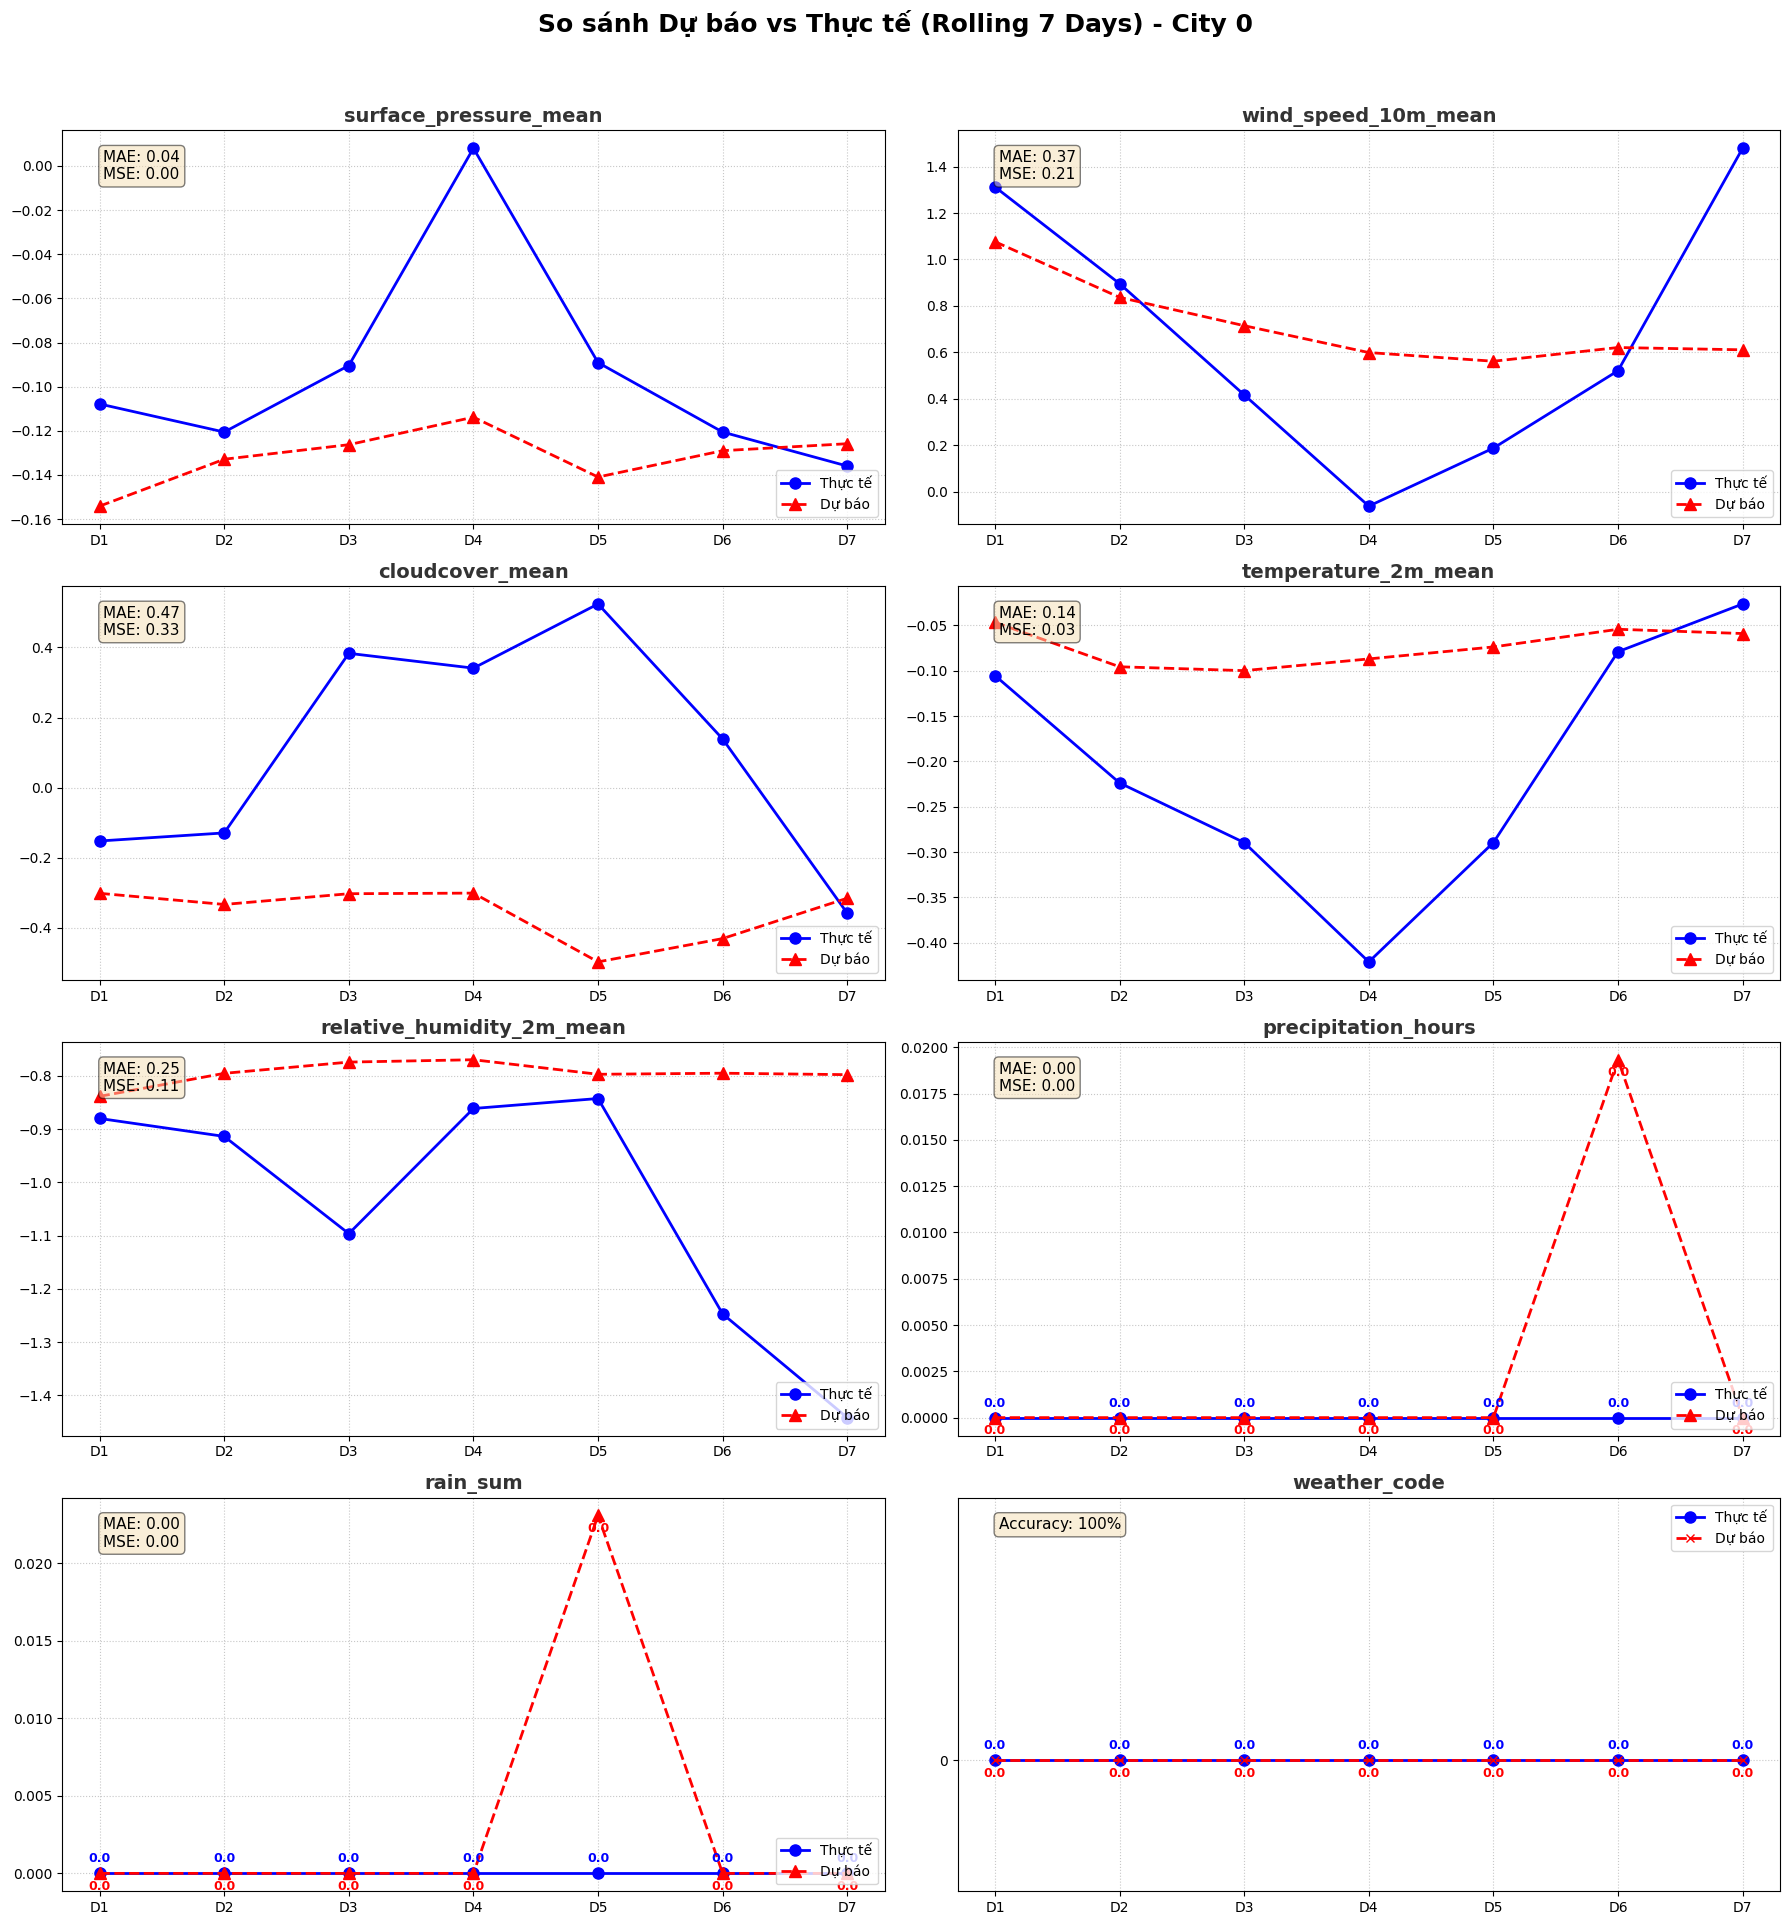

In [46]:
all_features = [
    'surface_pressure_mean', 'wind_speed_10m_mean', 'cloudcover_mean', 
    'temperature_2m_mean', 'relative_humidity_2m_mean', 
    'precipitation_hours', 'rain_sum', 'weather_code'
]

plot_data = {feat: {'pred': [], 'true': []} for feat in all_features}
metrics_text = {}

# Gom dữ liệu từ dict dự báo và dataframe thực tế
for i in range(7):
    day_key = f'day_{i+1}'
    for feat in all_features:
        plot_data[feat]['pred'].append(test_city_prediction[day_key][feat])
        plot_data[feat]['true'].append(true_day_0.iloc[i][feat])

print("\n>>> KẾT QUẢ ĐÁNH GIÁ (7 NGÀY):")
print("-" * 60)

for feat in all_features:
    y_true = plot_data[feat]['true']
    y_pred = plot_data[feat]['pred']
    
    if feat == 'weather_code':
        # Classification Metric
        acc = accuracy_score(y_true, y_pred)
        metrics_text[feat] = f"Accuracy: {acc:.0%}"
        print(f"{feat:<30} | Accuracy: {acc:.2f}")
    else:
        # Regression Metrics
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        metrics_text[feat] = f"MAE: {mae:.2f}\nMSE: {mse:.2f}"
        print(f"{feat:<30} | MAE: {mae:.4f} | MSE: {mse:.4f}")

# ==========================================
# 3. VẼ BIỂU ĐỒ (4 Hàng x 2 Cột)
# ==========================================
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
fig.suptitle('So sánh Dự báo vs Thực tế (Rolling 7 Days) - City 0', fontsize=18, fontweight='bold', y=0.98)
axes = axes.flatten()
days_label = [f"D{i+1}" for i in range(7)]

for i, feat in enumerate(all_features):
    ax = axes[i]
    y_true = plot_data[feat]['true']
    y_pred = plot_data[feat]['pred']
    
    # Vẽ đường thực tế
    ax.plot(days_label, y_true, 'b-o', label='Thực tế', linewidth=2, markersize=8)
    
    # Vẽ đường dự báo (Style khác nhau cho Weather Code)
    if feat == 'weather_code':
        ax.step(days_label, y_pred, 'r--x', where='mid', label='Dự báo', linewidth=2)
        ax.set_ylim(-0.5, max(max(y_true), max(y_pred)) + 1)
        ax.set_yticks(sorted(list(set(y_true).union(set(y_pred))))) # Chỉ hiện các tick code có xuất hiện
    else:
        ax.plot(days_label, y_pred, 'r--^', label='Dự báo', linewidth=2, markersize=8)
    
    # Trang trí
    ax.set_title(f"{feat}", fontsize=14, fontweight='bold', color='#333333')
    
    # Hiển thị Metrics ngay trong biểu đồ (Góc trên bên trái/phải)
    ax.text(0.05, 0.95, metrics_text[feat], transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower right' if feat != 'weather_code' else 'upper right')
    
    # Annotate giá trị cho các biến quan trọng
    if feat in ['rain_sum', 'weather_code', 'precipitation_hours']:
        for j, val in enumerate(y_true):
            ax.annotate(f"{val:.1f}", (j, val), xytext=(0, 8), textcoords='offset points', ha='center', color='blue', fontsize=9, fontweight='bold')
        for j, val in enumerate(y_pred):
            ax.annotate(f"{val:.1f}", (j, val), xytext=(0, -12), textcoords='offset points', ha='center', color='red', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0.02, 1, 0.96]) # Căn chỉnh lề
plt.show()

RANDOMFOREST

In [43]:
test_city_prediction, test_city_data = predict_weather_chain(reg_chain_rf, clf_chain_rf, day_0)

Index(['city', 'latitude', 'longitude', 'dewpoint_2m_mean', 'year',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofweek_sin',
       'dayofweek_cos', 'quarter_sin', 'quarter_cos', 'rain_sum_lag_1',
       'weather_code_lag_1', 'precipitation_hours_lag_1', 'rain_sum_lag_2',
       'weather_code_lag_2', 'precipitation_hours_lag_2', 'rain_sum_lag_3',
       'weather_code_lag_3', 'precipitation_hours_lag_3', 'rain_sum_lag_7',
       'weather_code_lag_7', 'precipitation_hours_lag_7',
       'rain_sum_rolling_mean_3', 'weather_code_rolling_mean_3',
       'precipitation_hours_rolling_mean_3', 'rain_sum_rolling_mean_7',
       'weather_code_rolling_mean_7', 'precipitation_hours_rolling_mean_7',
       'temperature_2m_mean_lag_1', 'relative_humidity_2m_mean_lag_1',
       'dewpoint_2m_mean_lag_1', 'surface_pressure_mean_lag_1',
       'cloudcover_mean_lag_1', 'wind_speed_10m_mean_lag_1',
       'temperature_2m_mean_lag_2', 'relative_humidity_2m_mean_lag_2',
       'dewpoint_2m_me


>>> KẾT QUẢ ĐÁNH GIÁ (7 NGÀY):
------------------------------------------------------------
surface_pressure_mean          | MAE: 0.0825 | MSE: 0.0081
wind_speed_10m_mean            | MAE: 0.5353 | MSE: 0.3682
cloudcover_mean                | MAE: 0.6043 | MSE: 0.4665
temperature_2m_mean            | MAE: 0.1602 | MSE: 0.0407
relative_humidity_2m_mean      | MAE: 0.1775 | MSE: 0.0419
precipitation_hours            | MAE: 0.7987 | MSE: 0.6972
rain_sum                       | MAE: 0.1911 | MSE: 0.0373
weather_code                   | Accuracy: 1.00


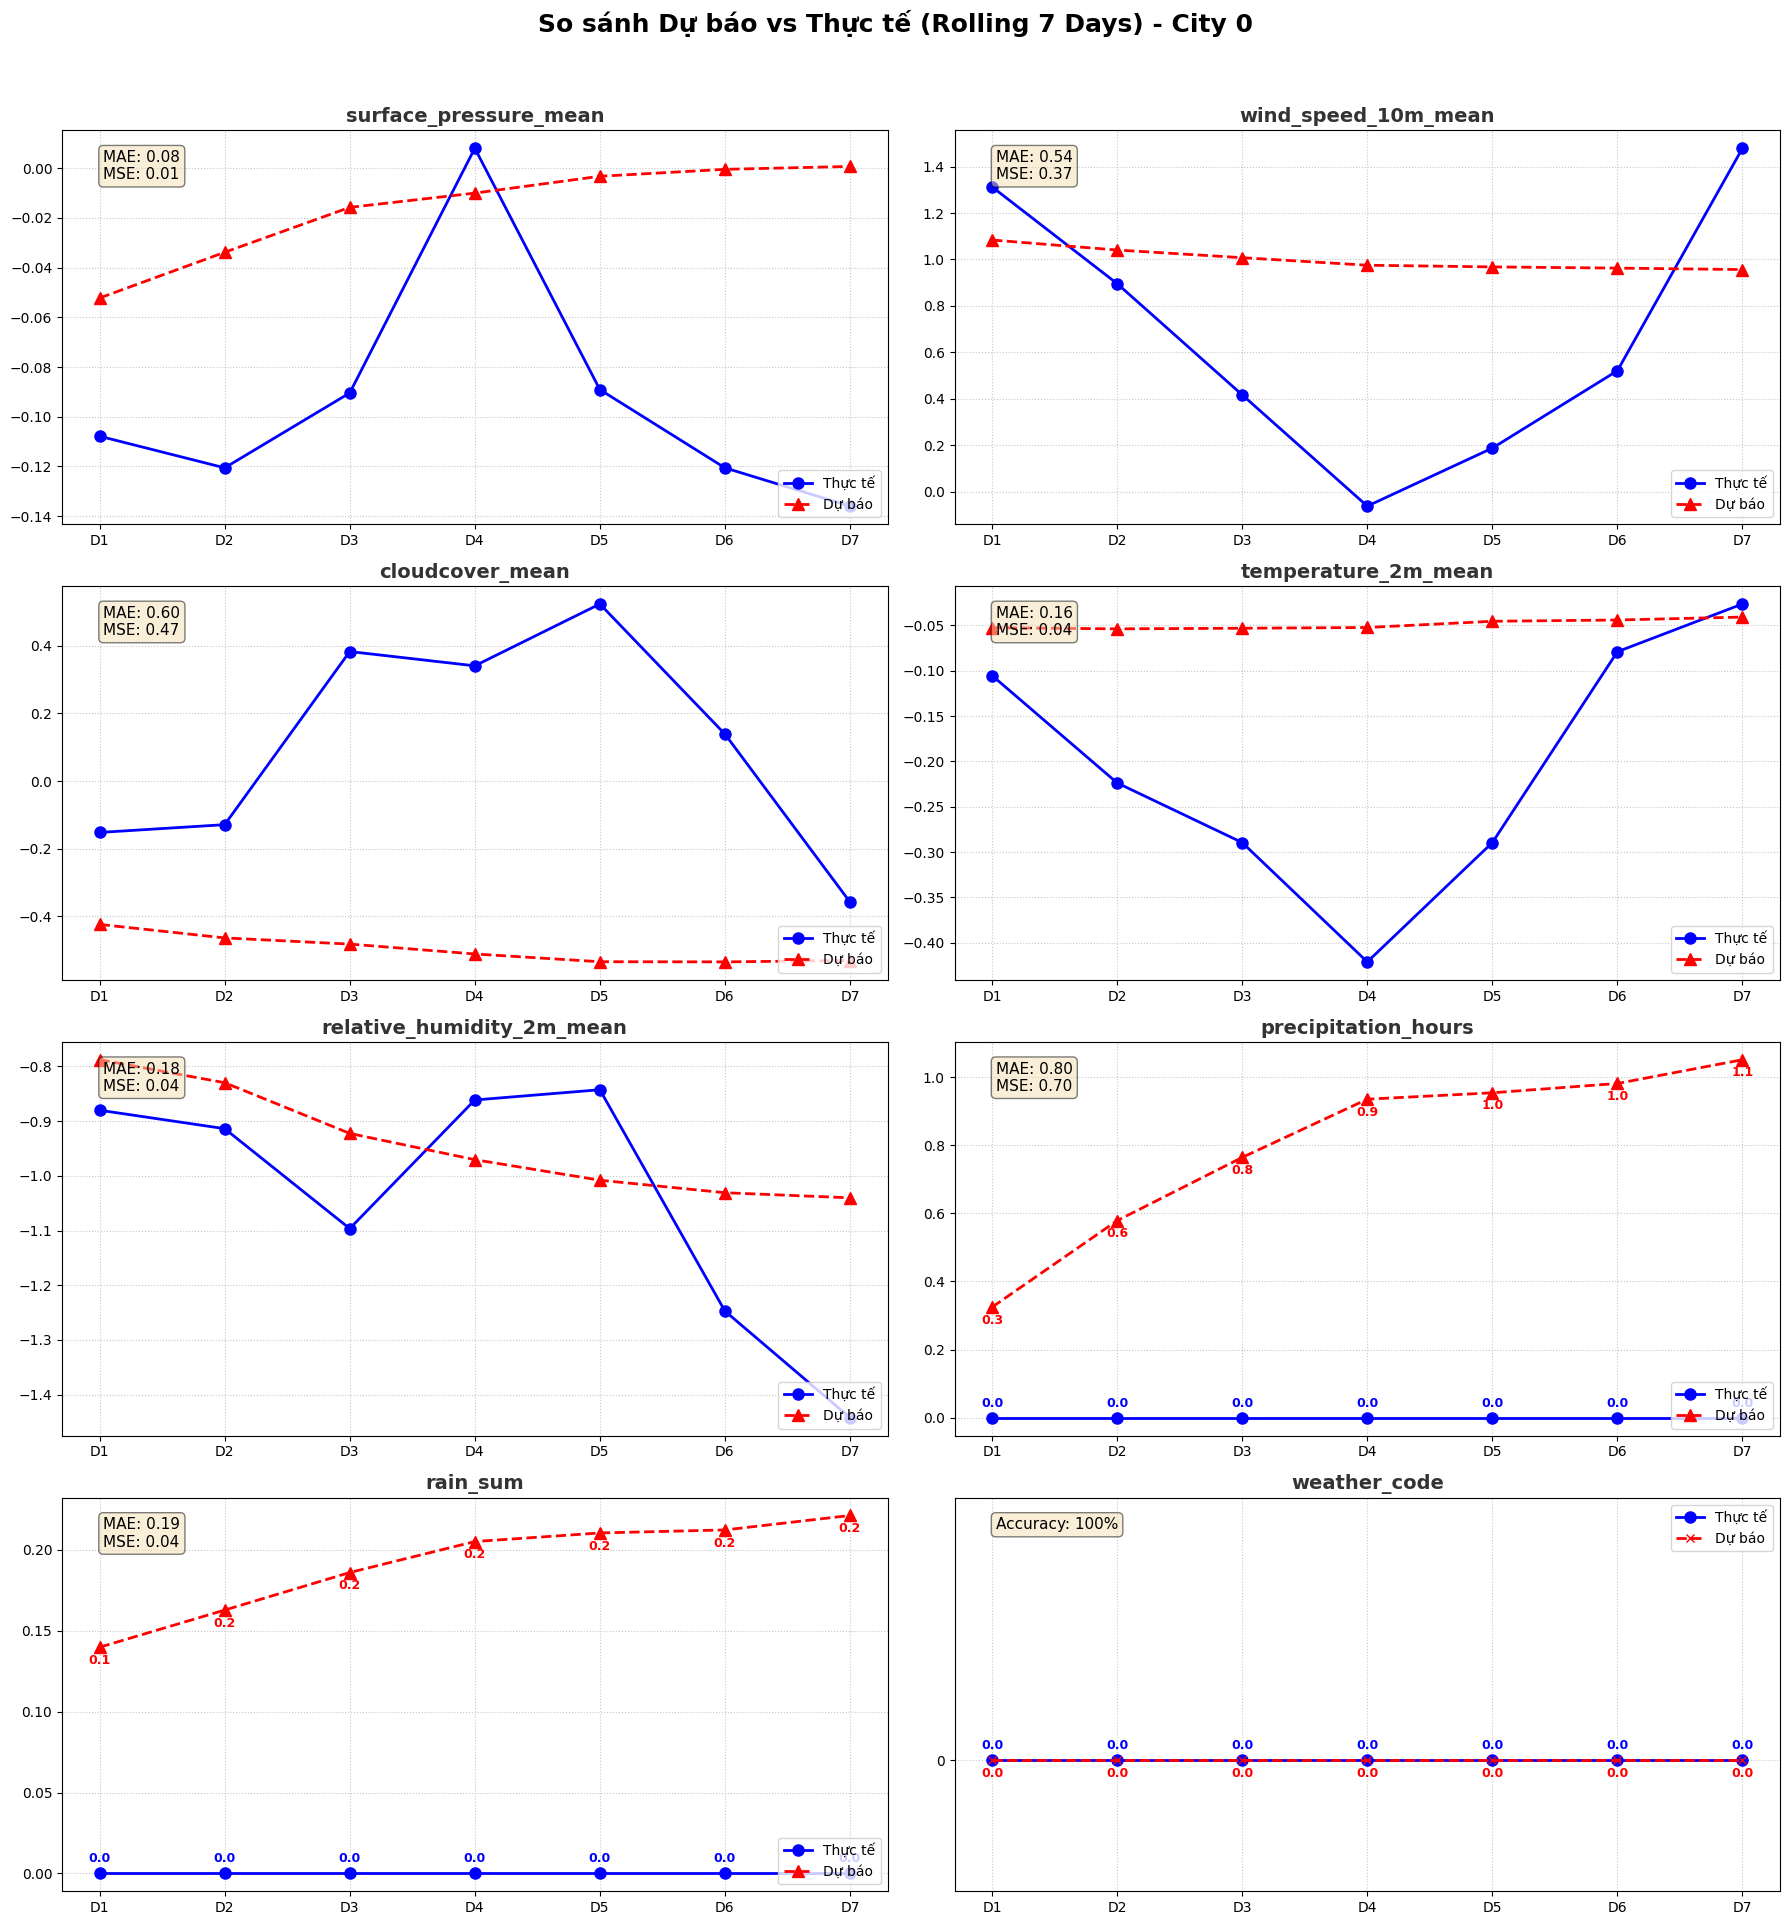

In [44]:
all_features = [
    'surface_pressure_mean', 'wind_speed_10m_mean', 'cloudcover_mean', 
    'temperature_2m_mean', 'relative_humidity_2m_mean', 
    'precipitation_hours', 'rain_sum', 'weather_code'
]

plot_data = {feat: {'pred': [], 'true': []} for feat in all_features}
metrics_text = {}

# Gom dữ liệu từ dict dự báo và dataframe thực tế
for i in range(7):
    day_key = f'day_{i+1}'
    for feat in all_features:
        plot_data[feat]['pred'].append(test_city_prediction[day_key][feat])
        plot_data[feat]['true'].append(true_day_0.iloc[i][feat])

print("\n>>> KẾT QUẢ ĐÁNH GIÁ (7 NGÀY):")
print("-" * 60)

for feat in all_features:
    y_true = plot_data[feat]['true']
    y_pred = plot_data[feat]['pred']
    
    if feat == 'weather_code':
        # Classification Metric
        acc = accuracy_score(y_true, y_pred)
        metrics_text[feat] = f"Accuracy: {acc:.0%}"
        print(f"{feat:<30} | Accuracy: {acc:.2f}")
    else:
        # Regression Metrics
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        metrics_text[feat] = f"MAE: {mae:.2f}\nMSE: {mse:.2f}"
        print(f"{feat:<30} | MAE: {mae:.4f} | MSE: {mse:.4f}")

# ==========================================
# 3. VẼ BIỂU ĐỒ (4 Hàng x 2 Cột)
# ==========================================
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
fig.suptitle('So sánh Dự báo vs Thực tế (Rolling 7 Days) - City 0', fontsize=18, fontweight='bold', y=0.98)
axes = axes.flatten()
days_label = [f"D{i+1}" for i in range(7)]

for i, feat in enumerate(all_features):
    ax = axes[i]
    y_true = plot_data[feat]['true']
    y_pred = plot_data[feat]['pred']
    
    # Vẽ đường thực tế
    ax.plot(days_label, y_true, 'b-o', label='Thực tế', linewidth=2, markersize=8)
    
    # Vẽ đường dự báo (Style khác nhau cho Weather Code)
    if feat == 'weather_code':
        ax.step(days_label, y_pred, 'r--x', where='mid', label='Dự báo', linewidth=2)
        ax.set_ylim(-0.5, max(max(y_true), max(y_pred)) + 1)
        ax.set_yticks(sorted(list(set(y_true).union(set(y_pred))))) # Chỉ hiện các tick code có xuất hiện
    else:
        ax.plot(days_label, y_pred, 'r--^', label='Dự báo', linewidth=2, markersize=8)
    
    # Trang trí
    ax.set_title(f"{feat}", fontsize=14, fontweight='bold', color='#333333')
    
    # Hiển thị Metrics ngay trong biểu đồ (Góc trên bên trái/phải)
    ax.text(0.05, 0.95, metrics_text[feat], transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower right' if feat != 'weather_code' else 'upper right')
    
    # Annotate giá trị cho các biến quan trọng
    if feat in ['rain_sum', 'weather_code', 'precipitation_hours']:
        for j, val in enumerate(y_true):
            ax.annotate(f"{val:.1f}", (j, val), xytext=(0, 8), textcoords='offset points', ha='center', color='blue', fontsize=9, fontweight='bold')
        for j, val in enumerate(y_pred):
            ax.annotate(f"{val:.1f}", (j, val), xytext=(0, -12), textcoords='offset points', ha='center', color='red', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0.02, 1, 0.96]) # Căn chỉnh lề
plt.show()